## Redoing preprocessing of fastq into sequences for analysis

The preprocessing script is at [preprocessing.py](preprocessing.py). 
* Switch from AA seqs to DNA seqs
  * num of mutants cutoff is now 15 base pairs instead of 10 residues
* No quality filtering is done
* Source fastq files are what Phil generated by using `bam2fastq`
* Source `bam` files are demuxed at `/mnt/rdrive/promero2/UWBC-Dropbox/Large Datasets/r64247_20210830_223032/2_B01/demux`

### Load in data

In [1]:
import gzip 

import Bio
import Bio.SeqIO

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


import utils

In [2]:
datadir = "../data/2D"
bin_dir = "../data/scratch/2D"

In [3]:
WT_fasta = Bio.SeqIO.read(datadir + "/2D.fasta", format="fasta")
WT_DNA = WT_fasta.seq
WT = WT_DNA.translate()

WT_DNA = WT_fasta.seq
print("WT (in this case the 2D parent)")
print(repr(WT_DNA), repr(WT), sep="\n")

WT (in this case the 2D parent)
Seq('ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAGCACGTGCA...TGA')
Seq('MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDGERDAWWDD...FD*')


In [4]:
sample_info = pd.read_csv(f"{datadir}/sample_info.csv")

# pick up mapping between samples and bar code
# this file is originally from the sequencing data directory
# /mnt/rdrive/promero2/UWBC-Dropbox/Large Datasets/r64247_20210830_223032/2_B01
barcode_samples = pd.read_csv(f"{datadir}/00Samples", sep="\t")

# pick up information about each barcode
# this file is originally from the demuxed data directory
# /mnt/rdrive/promero2/UWBC-Dropbox/Large Datasets/r64247_20210830_223032/2_B01/demux
# info on the lima counts file format is here https://lima.how/output/counts.html
# *shows the counts of each observed barcode pair; only passing ZMWs are counted*
lima_counts = pd.read_csv(f"{datadir}/m64247_210901_044846.demux.lima.counts", sep="\t")
lima_counts["barcode"] = lima_counts["IdxFirstNamed"] + "--" + lima_counts["IdxFirstNamed"]

# merge all the barcode info
barcode_info = pd.merge(lima_counts[["barcode", "Counts"]], 
                        barcode_samples).rename(
             {"Sample name":"bin_name", "Counts":"lima_counts"}, axis=1)

# merge with sample info
sample_info = pd.merge(sample_info, barcode_info)
sample_info

,bin_num,bin_name,category,num_samples,response,barcode,lima_counts
0,1,2D-R1-B1,High Hydroxylation,14,3,bc1002_BAK8A_OA--bc1002_BAK8A_OA,138204
1,2,2D-R1-B2,Parent Hydroxylation,25,2,bc1009_BAK8A_OA--bc1009_BAK8A_OA,107094
2,3,2D-R1-B3,Low Hydroxylation,186,1,bc1010_BAK8A_OA--bc1010_BAK8A_OA,97711
3,4,2D-R1-B4,No Hydroxylation,675,0,bc1011_BAK8A_OA--bc1011_BAK8A_OA,46842
4,5,2D-R1-B5,High Azidation,16,3,bc1012_BAK8A_OA--bc1012_BAK8A_OA,99479
5,6,2D-R1-B6,Parent Azidation,27,2,bc1017_BAK8B_OA--bc1017_BAK8B_OA,119044
6,7,2D-R1-B7,Low Azidation,174,1,bc1018_BAK8B_OA--bc1018_BAK8B_OA,108627
7,8,2D-R1-B8,No Azidation,683,0,bc1022_BAK8B_OA--bc1022_BAK8B_OA,77924


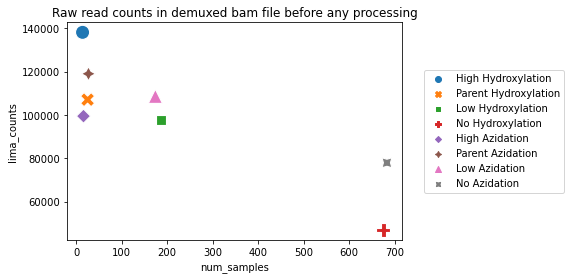

In [5]:
g = sns.scatterplot(data=sample_info, x="num_samples", y="lima_counts", 
                    hue="category", style="category", s=200)
g.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), ncol=1)
g.set_title("Raw read counts in demuxed bam file before any processing")
pass

* The *No Hydroxylation* and *No Azidization* groups have the largest number of samples but the smallest number of total reads. **Why?** 

In [6]:
def read_text_file(filename): 
    """Read plain text file"""
    opener = open
    if filename.endswith(".gz"):
        opener = gzip.open
    with opener(filename, "rt") as fh:
        return [line.strip() for line in fh]

In [7]:
# read in all the sequences from all the bins
# a count the unique sequences (i.e. make histograms)
bin_pd_list = list()
for bin_num in sample_info.bin_num:
    bin_seqs = read_text_file(bin_dir + f"/bin{bin_num}_sequences.txt.gz")
    bin_pd = pd.DataFrame(bin_seqs, columns=["sequence"])
    bin_pd_unique = bin_pd.sequence.value_counts().reset_index()
    bin_pd_unique.columns = ["sequence", "read_count"]
    bin_pd_unique["bin_num"] = bin_num
    bin_pd_unique = bin_pd_unique.reset_index()
    bin_pd_unique.rename(columns={'index':'seq_idx'}, inplace=True)
    bin_pd_unique["seq_idx"] += 1 # so that we can take log of seq_idx
    # fraction of the read count in this bin
    bin_pd_unique["count_frac_bin"] = bin_pd_unique.read_count \
                                        / bin_pd_unique.read_count.sum()
    bin_pd_list.append(bin_pd_unique)
    
# concatenate all the bin lists
df = pd.concat(bin_pd_list, ignore_index=True)
df["bin_num"] = pd.Categorical(df["bin_num"])
df["is_wt"] = (df.sequence == WT_DNA)

# convert sequence to amino acids
df["sequence_aa"] = df.sequence.map(lambda x: str(Bio.Seq.Seq(x).translate()))
df["is_wt_aa"] = (df.sequence_aa == WT)
df["first_stop"] = df.sequence_aa.str.find("*")
df["is_trunc"] = (df.first_stop != (len(WT) - 1))
df["is_not_trunc"] = ~ df["is_trunc"]

In [8]:
df_wt = df[df.is_wt == True] # only select sequence that match the parent in this dataframe

In [9]:
cutoffs = {}

# Hydroxylation
cutoffs[1] = 750
cutoffs[2] = 750 
cutoffs[3] = 50 
cutoffs[4] = 10 
hydroxy_bins = [1,2,3,4]

# Azidization
cutoffs[5] = 750
cutoffs[6] = 750
cutoffs[7] = 50
cutoffs[8] = 10
azid_bins = [5,6,7,8]

### Read counts from Pacbio sequencing

* Marking the location of the WT DNA sequence

In [10]:
seq_type = pd.Series(df.is_wt_aa * 1  + df.is_trunc * 2, dtype="category")
seq_type.cat.categories = ["normal", "parent_aa", "stop_codons"]
df["seq_type"] = seq_type

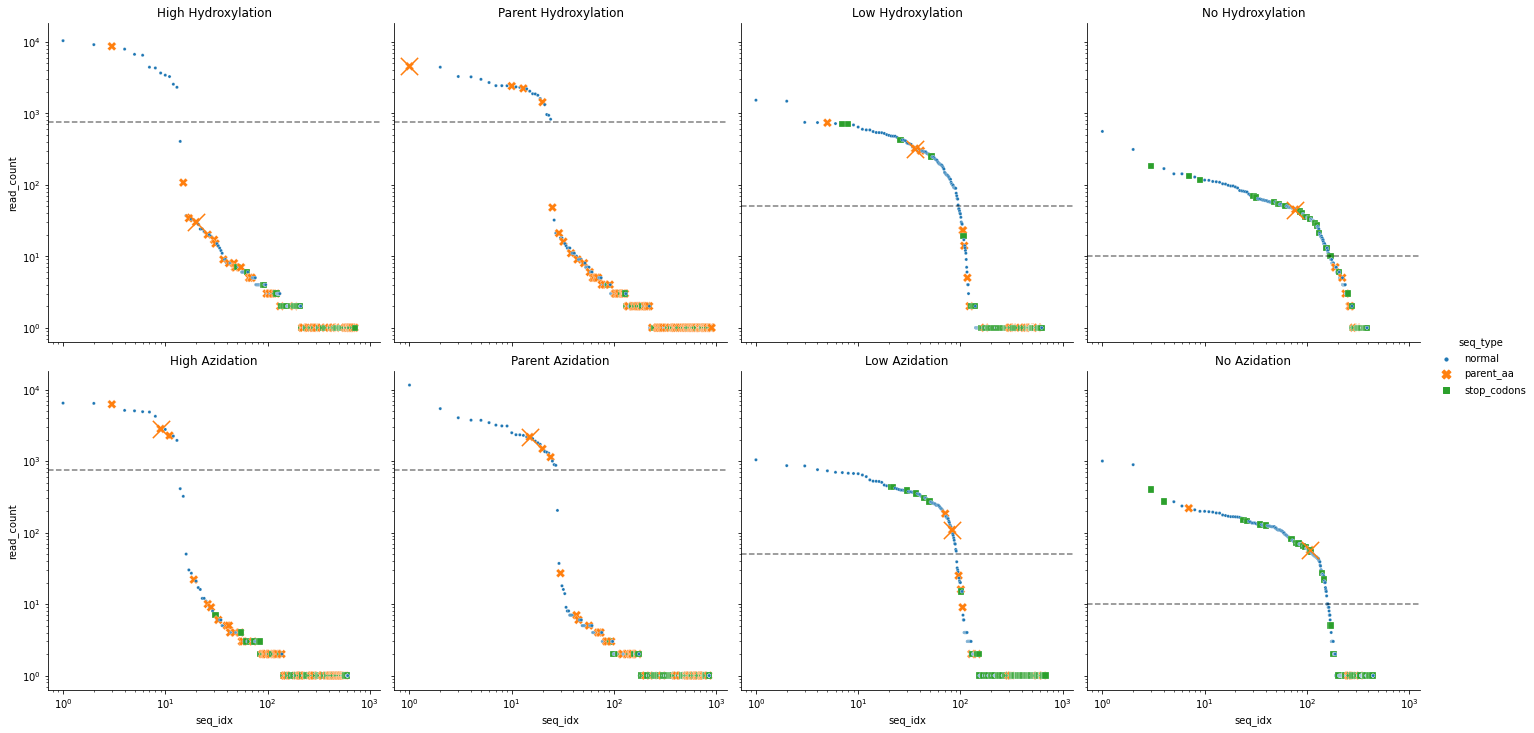

In [11]:
grid = sns.relplot(data=df, x="seq_idx", y="read_count", 
                    style="seq_type", hue="seq_type", 
                    size="seq_type", 
                    sizes={"normal":10, "parent_aa":80, "stop_codons":80},
                    col="bin_num", col_wrap=4)
grid.set(xscale="log", yscale="log")
for bin_num, ax in grid.axes_dict.items():      
    df_wt_bin = df_wt[df_wt.bin_num == bin_num]
    ax.set_title(sample_info.category[sample_info.bin_num == bin_num].item())
    ax.scatter(df_wt_bin.seq_idx, df_wt_bin.read_count, marker="x", 
               s=300, color="tab:orange")
    ax.axhline(cutoffs[bin_num], linestyle="--", color="black", alpha=0.5)
    
plt.savefig("../output/2D/preprocessing_stats.png", dpi=300)
pass

* Hydroxylation (bins 1-4)
  * Parent 2D appears dominant in bin 2 (Parent Hydroxylation) only and not in other bins. 
* Azidization (Bins 5-8)
  * Parent 2D doesn't stand out in any bin. Looks best in Bin 5 (High Azidation).

In [12]:
sample_info["num_reads"] = np.zeros(len(sample_info), dtype=int)
sample_info["num_unique"] = np.zeros(len(sample_info), dtype=int)
sample_info["WT_rank"] = np.zeros(len(sample_info), dtype=int) * -1
sample_info["WT_pct"] = np.zeros(len(sample_info), dtype=int)

In [13]:
df_by_bin = df.groupby("bin_num")
for bin_num, bin_data in df_by_bin:
    bin_mask = (sample_info.bin_num == bin_num)
    num_reads = bin_data.read_count.sum()
    sample_info.loc[bin_mask, "num_reads"] = num_reads
    sample_info.loc[bin_mask, "num_unique"] = len(bin_data)
    bin_wt = bin_data[bin_data.is_wt == True]
    sample_info.loc[bin_mask, "WT_rank"] = int(bin_wt.seq_idx.item())
    sample_info.loc[bin_mask, "WT_pct"] = int(bin_wt.read_count.item() / num_reads * 100)

In [14]:
sample_info # cutoffs

,bin_num,bin_name,category,num_samples,response,barcode,lima_counts,num_reads,num_unique,WT_rank,WT_pct
0,1,2D-R1-B1,High Hydroxylation,14,3,bc1002_BAK8A_OA--bc1002_BAK8A_OA,138204,74963,714,20,0
1,2,2D-R1-B2,Parent Hydroxylation,25,2,bc1009_BAK8A_OA--bc1009_BAK8A_OA,107094,55970,900,1,8
2,3,2D-R1-B3,Low Hydroxylation,186,1,bc1010_BAK8A_OA--bc1010_BAK8A_OA,97711,32457,623,36,0
3,4,2D-R1-B4,No Hydroxylation,675,0,bc1011_BAK8A_OA--bc1011_BAK8A_OA,46842,9377,388,77,0
4,5,2D-R1-B5,High Azidation,16,3,bc1012_BAK8A_OA--bc1012_BAK8A_OA,99479,57018,609,9,4
5,6,2D-R1-B6,Parent Azidation,27,2,bc1017_BAK8B_OA--bc1017_BAK8B_OA,119044,73299,855,15,2
6,7,2D-R1-B7,Low Azidation,174,1,bc1018_BAK8B_OA--bc1018_BAK8B_OA,108627,31568,680,83,0
7,8,2D-R1-B8,No Azidation,683,0,bc1022_BAK8B_OA--bc1022_BAK8B_OA,77924,16263,446,107,0


### Add cutoffs

In [15]:
df_cutoff = pd.concat([bin_data[bin_data.read_count >= cutoffs[bin_num]] 
                       for bin_num, bin_data in df_by_bin])

### Save cutoff dataframe for further processing

# convert bin number 1-8 to response code
df_cutoff["response"] = sample_info.response.to_numpy()[df_cutoff.bin_num.to_numpy() - 1] 
df_cutoff

,seq_idx,sequence,read_count,bin_num,count_frac_bin,is_wt,sequence_aa,is_wt_aa,first_stop,is_trunc,is_not_trunc,seq_type,response
0,1,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,10336,1,0.137881,False,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,False,273,False,True,normal,3
1,2,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,9102,1,0.121420,False,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,False,273,False,True,normal,3
2,3,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,8612,1,0.114883,False,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,True,273,False,True,parent_aa,3
3,4,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,7872,1,0.105012,False,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADKADAIVMDIVPDG...,False,273,False,True,normal,3
4,5,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGCCACCGCAG...,6654,1,0.088764,False,MQHTYPAQLMRFATAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,False,273,False,True,normal,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4925,157,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGTACCGCAG...,10,8,0.000615,False,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,False,273,False,True,normal,0
4926,158,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,10,8,0.000615,False,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,False,273,False,True,normal,0
4927,159,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTAGGCGCCGCAG...,10,8,0.000615,False,MQHTYPAQLMRLGAAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,False,273,False,True,normal,0
4928,160,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,10,8,0.000615,False,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMYIVPDG...,False,273,False,True,normal,0


In [16]:
df_cutoff_bin = df_cutoff.groupby('bin_num')
print("Cutoff dataframe stats")
pd.concat([sample_info.groupby("bin_num").num_samples.first(),
         df_cutoff_bin.read_count.count(),
         df_cutoff_bin.is_wt.sum(),
         df_cutoff_bin.is_wt_aa.sum(),
         df_cutoff_bin.is_trunc.sum()], axis=1)

Cutoff dataframe stats


,num_samples,read_count,is_wt,is_wt_aa,is_trunc
bin_num,,,,,
1,14,13,0,1,0
2,25,24,1,4,0
3,186,95,1,3,4
4,675,171,1,1,22
5,16,13,1,3,0
6,27,27,1,3,0
7,174,91,1,2,6
8,683,161,1,2,15


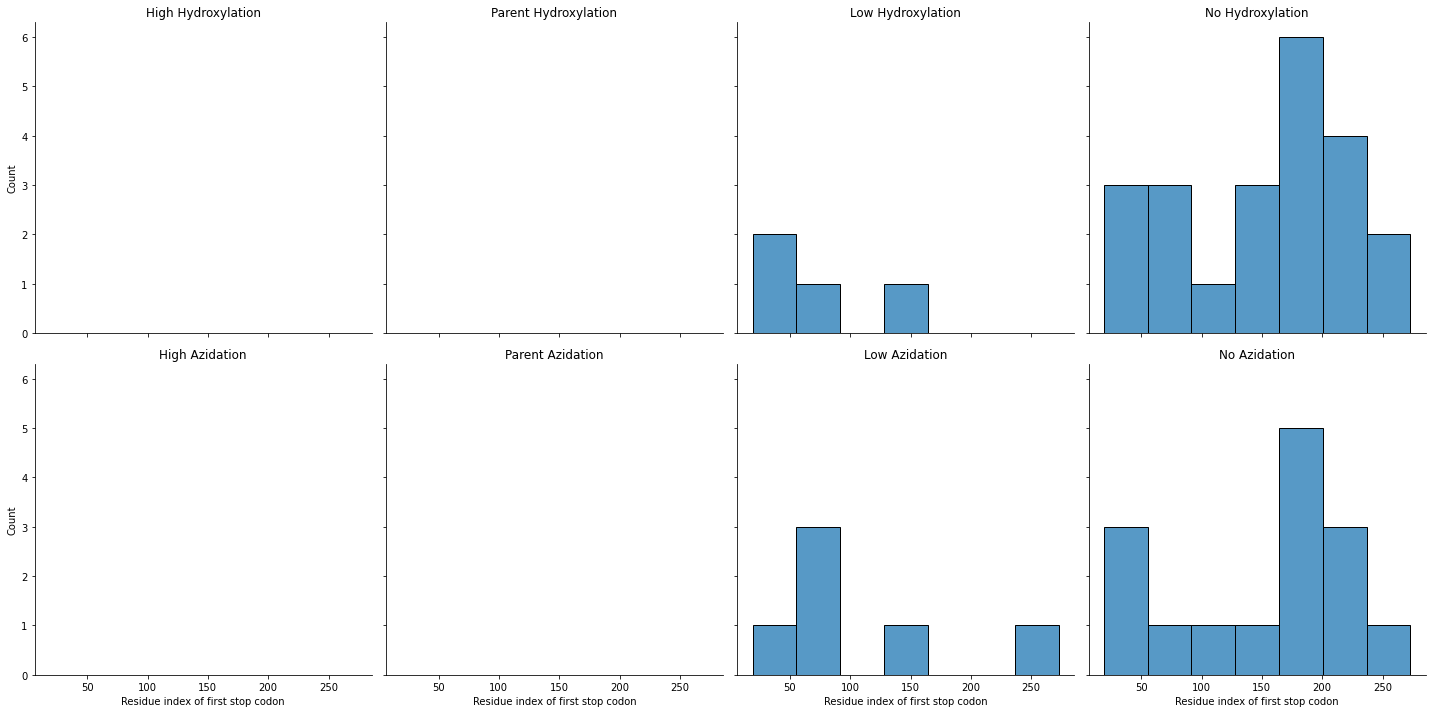

In [17]:
#Location of first stop codon after cutoffs are fixed
df_stop = df_cutoff[df_cutoff.first_stop != 273].copy()
df_stop["first_stop_parent_idx"] = df_stop.first_stop + 1
grid = sns.displot(data=df_stop, x="first_stop_parent_idx", col="bin_num", kind="hist", col_wrap=4)
for bin_num, ax in grid.axes_dict.items():      
    df_wt_bin = df_wt[df_wt.bin_num == bin_num]
    ax.set_title(sample_info.category[sample_info.bin_num == bin_num].item())
    if bin_num in azid_bins:
        ax.set_xlabel("Residue index of first stop codon")

In [18]:
df_hydroxy = df_cutoff[df_cutoff.bin_num.isin(hydroxy_bins)].copy()
df_azid = df_cutoff[df_cutoff.bin_num.isin(azid_bins)].copy()

In [19]:
df_hydroxy.to_pickle(f"{bin_dir}/hydroxy.pkl")
df_azid.to_pickle(f"{bin_dir}/azid.pkl")

In [20]:
df_azid.head()

,seq_idx,sequence,read_count,bin_num,count_frac_bin,is_wt,sequence_aa,is_wt_aa,first_stop,is_trunc,is_not_trunc,seq_type,response
2625,1,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,6459,5,0.113280,False,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,False,273,False,True,normal,3
2626,2,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,6401,5,0.112263,False,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,False,273,False,True,normal,3
2627,3,ATGCAGCATACCTATCCGGCTCAGCTGATGCGTTTTGGCACCGCGG...,6222,5,0.109123,False,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,True,273,False,True,parent_aa,3
2628,4,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,5110,5,0.089621,False,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,False,273,False,True,normal,3
2629,5,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,5039,5,0.088376,False,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,False,273,False,True,normal,3


### Mutation rate

Calculate the DNA mutation rate of all the sequences in the library. (i.e. all sequences with read counts above the cutoffs in each bin). Only the sequences above the cutoffs are assumed to be valid sequences.  

In [21]:
hydroxy_muts = df_hydroxy.sequence.map(lambda x: utils.hamming_dist(x, WT_DNA))
azid_muts = df_azid.sequence.map(lambda x: utils.hamming_dist(x, WT_DNA))

In [22]:
print(f"Hydroxylation mutations, mean: {hydroxy_muts.mean():.2f}, std : {hydroxy_muts.std():.2f}")
print(f"Azidation mutations    , mean: {azid_muts.mean():.2f}, std : {azid_muts.std():.2f}")

Hydroxylation mutations, mean: 4.93, std : 2.33
Azidation mutations    , mean: 5.12, std : 2.42


### Mutant in bin 5 (high aziadation) that translated to WT

In [23]:
# all sequences that translated into WT AA sequence in bin 5
df_azid[(df_azid.bin_num == 5) & (df_azid.is_wt_aa)]

,seq_idx,sequence,read_count,bin_num,count_frac_bin,is_wt,sequence_aa,is_wt_aa,first_stop,is_trunc,is_not_trunc,seq_type,response
2627,3,ATGCAGCATACCTATCCGGCTCAGCTGATGCGTTTTGGCACCGCGG...,6222,5,0.109123,False,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,True,273,False,True,parent_aa,3
2633,9,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,2817,5,0.049405,True,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,True,273,False,True,parent_aa,3
2635,11,ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAG...,2273,5,0.039865,False,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,True,273,False,True,parent_aa,3


In [24]:
# select the largest sequence as that is the one of interest
azid_high_wt = df_azid[(df_azid.bin_num == 5) & (df_azid.is_wt_aa) & (df_azid.count_frac_bin > 0.1)]

# convert to a mutation string
azid_high_wt_dna_muts = utils.mut_as_string(azid_high_wt.iloc[0].sequence, WT_DNA, mut_sep=", ", offset=1)
print("Sequence with high azidation but translated into WT")
print("---------------------------------------------------")
print("Location of DNA mutations : ", azid_high_wt_dna_muts)
print("Same location info but using the protein index : ", end="")
for i, mut in enumerate(azid_high_wt_dna_muts.split(",")):
    mut = mut.strip()
    # put mutation index back into python index
    mut_dna_idx = (int(mut[1:-1]) - 1)
    # python index for WT AA sequence
    mut_aa_idx = mut_dna_idx // 3
    print(f"{', ' if i else ''}{WT[mut_aa_idx]}{mut_aa_idx + 1}"
          f"{azid_high_wt.iloc[0].sequence_aa[mut_aa_idx]}",
          end="" )

Sequence with high azidation but translated into WT
---------------------------------------------------
Location of DNA mutations :  A21T, A45G, A198G, A633T, T672A
Same location info but using the protein index : A7A, A15A, A66A, A211A, R224R